In [11]:
# ==========================================
# 1. Mount Google Drive
# ==========================================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
# ==========================================
# 2. Import Library & Setup Style Akademik
# ==========================================
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

# Pengaturan font dan style untuk standar akademik
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.0

In [13]:
# ==========================================
# 3. Path Direktori Labeling & Output
# ==========================================
base_path = "/content/drive/My Drive/skripsi/dataset/mbg_2025/labeling_human/"

# Path 3 direktori batch yang berbeda
dir_1 = os.path.join(base_path, "refill_batches_350_validated/*.csv")
dir_2 = os.path.join(base_path, "refill_batches_validated/*.csv")
dir_3 = os.path.join(base_path, "seed_batches_validated/*.csv")

# Folder output
output_dir = "/content/drive/My Drive/skripsi/dataset/mbg_2025/final_data/"
os.makedirs(output_dir, exist_ok=True)

# Path Output File
output_chart = os.path.join(output_dir, "chart_human_labeling_sentiment.png")
output_irrelevant_csv = os.path.join(output_dir, "mbg_irrelevant_extracted.csv") # File baru untuk Irrelevant

In [14]:
# ==========================================
# 4. Load Data, Rekapitulasi & Ekstraksi
# ==========================================
print("Membaca file dari direktori labeling...")

# Mengumpulkan semua path file CSV dari ketiga direktori
all_files = glob.glob(dir_1) + glob.glob(dir_2) + glob.glob(dir_3)
print(f"Total ditemukan {len(all_files)} file CSV.")

dfs = []
count_success = 0

for file in all_files:
    try:
        # Membaca seluruh kolom agar saat diekstrak datanya utuh
        df_temp = pd.read_csv(file)
        if 'sentiment' in df_temp.columns:
            dfs.append(df_temp)
            count_success += 1
        else:
            print(f"⚠️ Kolom 'sentiment' tidak ditemukan pada file: {os.path.basename(file)}")
    except Exception as e:
        print(f"⚠️ Gagal membaca {os.path.basename(file)}: {e}")

# Menggabungkan semua dataframe menjadi satu
if dfs:
    df_all = pd.concat(dfs, ignore_index=True)

    # Cleaning data (Hilangkan spasi kosong dan buat format Title Case: "Positive")
    df_all['clean_sentiment'] = df_all['sentiment'].astype(str).str.strip().str.title()

    # Filter hanya kategori yang valid untuk menghindari data noise/NaN
    valid_labels = ['Positive', 'Neutral', 'Negative', 'Irrelevant']
    df_filtered = df_all[df_all['clean_sentiment'].isin(valid_labels)]

    # Menghitung distribusi sesuai urutan
    label_counts = df_filtered['clean_sentiment'].value_counts().reindex(valid_labels, fill_value=0)
    total_data = label_counts.sum()

    # =========================
    # EKSTRAKSI DATA IRRELEVANT
    # =========================
    df_irrelevant = df_all[df_all['clean_sentiment'] == 'Irrelevant'].copy()

    # Membuang kolom bantuan 'clean_sentiment' agar file CSV kembali seperti format asli
    df_irrelevant = df_irrelevant.drop(columns=['clean_sentiment'], errors='ignore')
    df_irrelevant.to_csv(output_irrelevant_csv, index=False)

    # =========================
    # Data Summary Output
    # =========================
    print("\n📊 Summary Distribusi Label Sentimen (Manual):")
    print(f"Total Data Tervalidasi : {total_data}")
    print("-" * 45)
    for label, count in label_counts.items():
        pct = (count / total_data) * 100 if total_data > 0 else 0
        print(f"- {label:<12} : {count:>5} ({pct:.1f}%)")
    print("-" * 45)
    print(f"\n✅ Data 'Irrelevant' berhasil diekstrak ({len(df_irrelevant)} baris) ke:\n{output_irrelevant_csv}")
else:
    print("❌ Tidak ada data yang berhasil dimuat.")
    label_counts = pd.Series(dtype=int)

Membaca file dari direktori labeling...
Total ditemukan 36 file CSV.

📊 Summary Distribusi Label Sentimen (Manual):
Total Data Tervalidasi : 6840
---------------------------------------------
- Positive     :  2649 (38.7%)
- Neutral      :  1949 (28.5%)
- Negative     :  2079 (30.4%)
- Irrelevant   :   163 (2.4%)
---------------------------------------------

✅ Data 'Irrelevant' berhasil diekstrak (163 baris) ke:
/content/drive/My Drive/skripsi/dataset/mbg_2025/final_data/mbg_irrelevant_extracted.csv



💾 Chart Hasil Pelabelan berhasil disimpan di:
/content/drive/My Drive/skripsi/dataset/mbg_2025/final_data/chart_human_labeling_sentiment.png



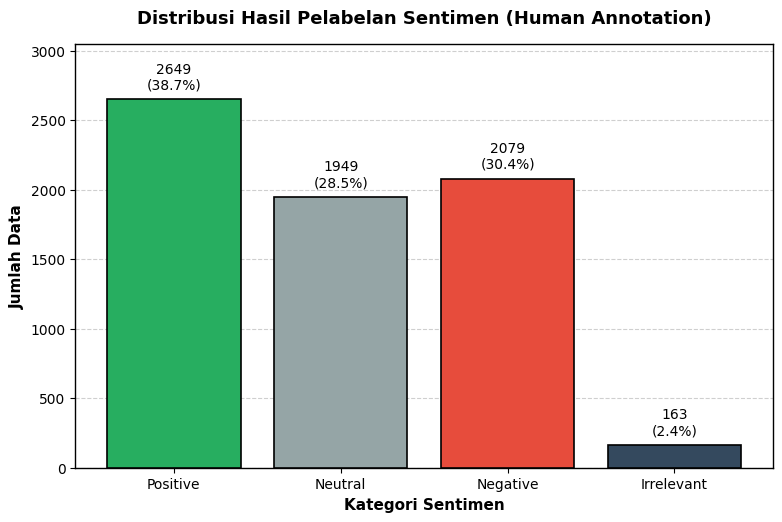

In [15]:
# ==========================================
# 5. Visualisasi Distribusi Label Manual
# ==========================================
if not label_counts.empty:
    plt.figure(figsize=(9, 5.5))

    # --- Psikologi Warna ---
    color_map = {
        'Positive': '#27ae60',
        'Neutral' : '#95a5a6',
        'Negative': '#e74c3c',
        'Irrelevant': '#34495e'
    }
    colors = [color_map[label] for label in label_counts.index]

    # Plot Bar Chart
    bars = plt.bar(
        label_counts.index,
        label_counts.values,
        color=colors,
        edgecolor='black',
        linewidth=1.2,
        zorder=3
    )

    # Judul dan Label Sumbu
    plt.title("Distribusi Hasil Pelabelan Sentimen (Human Annotation)", fontsize=13, pad=15, fontweight='bold')
    plt.xlabel("Kategori Sentimen", fontsize=11, fontweight='bold')
    plt.ylabel("Jumlah Data", fontsize=11, fontweight='bold')

    # Grid line horizontal (di belakang bar)
    plt.grid(axis='y', linestyle='--', alpha=0.6, zorder=0)

    # Anotasi: Menambahkan nilai dan persentase di atas setiap bar
    offset = max(label_counts.values) * 0.02
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            percentage = (height / total_data) * 100
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height + offset,
                f"{int(height)}\n({percentage:.1f}%)",
                ha='center',
                va='bottom',
                fontsize=10
            )

    # Menambahkan space atas agar anotasi tidak terpotong (overflow)
    plt.ylim(0, max(label_counts.values) * 1.15)

    # Menyimpan Chart
    fig = plt.gcf()
    fig.savefig(
        output_chart,
        dpi=300,
        bbox_inches='tight',
        facecolor='white'
    )

    print(f"\n💾 Chart Hasil Pelabelan berhasil disimpan di:\n{output_chart}\n")
    plt.show()
else:
    print("❌ Tidak dapat membuat chart karena data kosong.")